In [1]:
import pandas as pd
from tashaphyne.stemming import ArabicLightStemmer
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [2]:
import pandas as pd
dataset = pd.read_csv("../../datasets/arapoems_dataset/AraPoems_Dataset.csv")

In [3]:
da2 = pd.DataFrame()
da2["poem"] = dataset["first_hemistich"]+" "+dataset["second_hemistich"]
da2["meter"] = dataset["meter"]

In [4]:
da2 = da2.dropna()

In [5]:
# to keep only bahers that have more than 3000 samples
data = da2
dfs = pd.DataFrame(data)
column_name = 'meter'
min_count = 3000
counts = dfs[column_name].value_counts()
frequent_values = counts[counts > min_count].index
filtered_df = dfs[dfs[column_name].isin(frequent_values)]

In [6]:
filtered_df["meter"].nunique()

17

In [7]:
filtered_df["meter"].value_counts()

meter
taweel         434929
kamel          402612
baseet         259353
khafif         170315
unspecified    153553
wafer          152863
rajaz           98606
ramel           83054
mutaqarib       67856
saree           60613
muashah         31234
munsarih        29603
mujtath         19059
hazaj            8803
madeed           8543
colloquial       6885
mutadarak        5816
Name: count, dtype: int64

In [8]:
df_sampled = filtered_df.groupby('meter').head(100)


In [9]:
df_sampled

,poem,meter
0,إيها جداب سيد الأعراب يا معدن الطعان والضراب,rajaz
1,يا طيب الأحساب والأنساب قم لي مقام سيدي شهاب,rajaz
2,بالعزم والحزم وبالعذاب شمر وقم يا ويك في النقاب,rajaz
4,إن الجنود حثها طلابها والأرقميون فذا شهابها,rajaz
5,مقدامها طعانها ضرابها زعيمها فارسها غلابها,rajaz
...,...,...
835117,وله نفس أنابت كان من أفضل عباده,colloquial
835122,يا قلب كم لك وأنت جاني ما تطرقك غيره من الفائزين,colloquial
835123,مالي أرى لك حال ثاني تبني وتهدم مطلبك كل حين,colloquial
835124,غرقت في بحر التماني غدا تبين حسرة المبطلين,colloquial


In [10]:
df_sampled_rest = filtered_df.groupby("meter").head(100)[250:]
df_sampled_rest = df_sampled_rest[df_sampled_rest["meter"] != "unspecified"]

In [11]:
df_sampled_rest["meter"].value_counts()

meter
ramel         100
hazaj         100
madeed        100
munsarih      100
mujtath       100
mutadarak     100
muashah       100
colloquial    100
saree          98
mutaqarib      94
rajaz          87
baseet         78
khafif         76
wafer          60
taweel         57
Name: count, dtype: int64

In [12]:
df_sampled = df_sampled[df_sampled["meter"] != "unspecified"]

In [13]:
len(df_sampled["meter"].value_counts())

16

In [11]:
# vectorizer = TfidfVectorizer(ngram_range=(1,10),max_features=20000)
# X = vectorizer.fit_transform(df_sampled["poem"])

In [14]:
fff, unique_names = pd.factorize(df_sampled['meter'])

In [17]:
unique_names

Index(['rajaz', 'khafif', 'baseet', 'taweel', 'wafer', 'kamel', 'saree',
       'mutaqarib', 'ramel', 'hazaj', 'madeed', 'munsarih', 'mujtath',
       'mutadarak', 'muashah', 'colloquial'],
      dtype='object')

In [18]:
fff

array([ 0,  0,  0, ..., 15, 15, 15])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(df_sampled["poem"], fff, test_size=0.2, random_state=42)

In [16]:
import os
os.environ['TORCH_USE_CUDA_DSA'] = '1'
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

texts = X_train  # 100 samples

labels = y_train

model_name = "../../pre_trained_models/akhooli"
tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=len(set(labels))
)
# if tokenizer.pad_token is None:
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id

def tokenize_function(examples):
    return tokenizer(
        examples,
        padding="max_length",
        truncation=True,
        max_length=128
    )


Loading weights: 100%|██████████| 292/292 [00:00<00:00, 1576.70it/s, Materializing param=transformer.wte.weight]             
GPT2ForSequenceClassification LOAD REPORT from: ../../pre_trained_models/akhooli
Key                                     | Status     | 
----------------------------------------+------------+-
transformer.h.{0...23}.attn.masked_bias | UNEXPECTED | 
transformer.h.{0...23}.attn.bias        | UNEXPECTED | 
lm_head.weight                          | UNEXPECTED | 
score.weight                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
train_tokenized = tokenize_function(X_train.to_list())
test_tokenized = tokenize_function(X_test.to_list())

In [18]:
ffff, unique_namesf = pd.factorize(df_sampled_rest['meter'])

In [19]:
pd.DataFrame({"a":ffff}).value_counts()

a 
5     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
6      98
1      94
4      87
2      78
7      76
3      60
0      57
Name: count, dtype: int64

In [20]:
last_test_tokenized = tokenize_function(df_sampled_rest["poem"][:500].to_list())

In [21]:
last_test_dataset = Dataset.from_dict({
    'input_ids': last_test_tokenized['input_ids'],
    'attention_mask': last_test_tokenized['attention_mask'],
    'label': ffff[:500]
})

In [22]:
test_dataset = Dataset.from_dict({
    'input_ids': test_tokenized['input_ids'],
    'attention_mask': test_tokenized['attention_mask'],
    'label': y_test
})

In [23]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
    }

In [24]:
train_dataset = Dataset.from_dict({
    'input_ids': train_tokenized['input_ids'],
    'attention_mask': train_tokenized['attention_mask'],
    'label': y_train
})

training_args = TrainingArguments(
    output_dir='../../models/poetry_classification_models/classify_by_bahr/arapoems_datatset_fine_tuning_akhooli_bahr_classification',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,  # Batch size for validation
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",  # Evaluate at the end of each epoch
    save_strategy="epoch",         # Save at each epoch
    load_best_model_at_end=True,   # Load the best model when finished
    metric_for_best_model="f1_macro",  # Which metric to use for best model
    greater_is_better=True,         # Higher F1 is better
    save_total_limit=2, 
)

# Create trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,

)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [25]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.047382,0.703781,0.781250,0.779901,0.781015
2,0.090625,0.688585,0.856250,0.851541,0.855618


Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.39s/it]


TrainOutput(global_step=320, training_loss=1.0261468494310975, metrics={'train_runtime': 213.3912, 'train_samples_per_second': 11.997, 'train_steps_per_second': 1.5, 'total_flos': 594400656752640.0, 'train_loss': 1.0261468494310975, 'epoch': 2.0})

In [ ]:
trainer.save_model("../../models/poetry_classification_models/classify_by_bahr/arapoems_datatset_fine_tuning_akhooli_bahr_classification/best")
tokenizer.save_pretrained("../../models/poetry_classification_models/classify_by_bahr/arapoems_datatset_fine_tuning_akhooli_bahr_classification/best")

In [20]:
# clf = Pipeline([
#     ('scaler', MaxAbsScaler()),
#     ('clf', MultinomialNB()),
# ])

# clf.fit(X_train, y_train)

In [21]:
# accuracy = clf.score(X_train, y_train)
# print(f"Train Accuracy: {accuracy * 100:.2f}%")
# accuracy = clf.score(X_test, y_test)
# print(f"Test Accuracy: {accuracy * 100:.2f}%")

In [28]:
X_test

949                  حجري عائدي نسبا ثم للمنذر إذ جلى الخمر
426          ومن أولاد يشكر كل سام طويل الباع كالقمر المنير
174        عفت الديار وباقي الأطلال ريح الصبا وتقلب الأحوال
137        دعاني دعوة والخيل تردي فما أدري أباسمي أم كناني؟
3328            لا نجعل الباطل حقا ولا نلظ دون الحق بالباطل
                                ...                        
7178                      يهز العنق الأجر د في مستأمن الشعب
389912                     حب المها عباده من كل بسام السرار
522       ملك النهار وأنت الليل مومسة ماء الرجال على فخذ...
118986                        وإن خرجت فإني أضيع بين العلوج
1806        ولقد تعلم تيم أنني نعم حشو الدرع في اليوم الكسف
Name: poem, Length: 320, dtype: object

In [26]:
predictions = trainer.predict(last_test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids


In [ ]:
# trainer.save_model('./best_final_model')
# tokenizer.save_pretrained('./best_final_model')

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.23s/it]


('./best_final_model/tokenizer_config.json',
 './best_final_model/tokenizer.json')

/tmp/ipykernel_14273/379528460.py:12: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


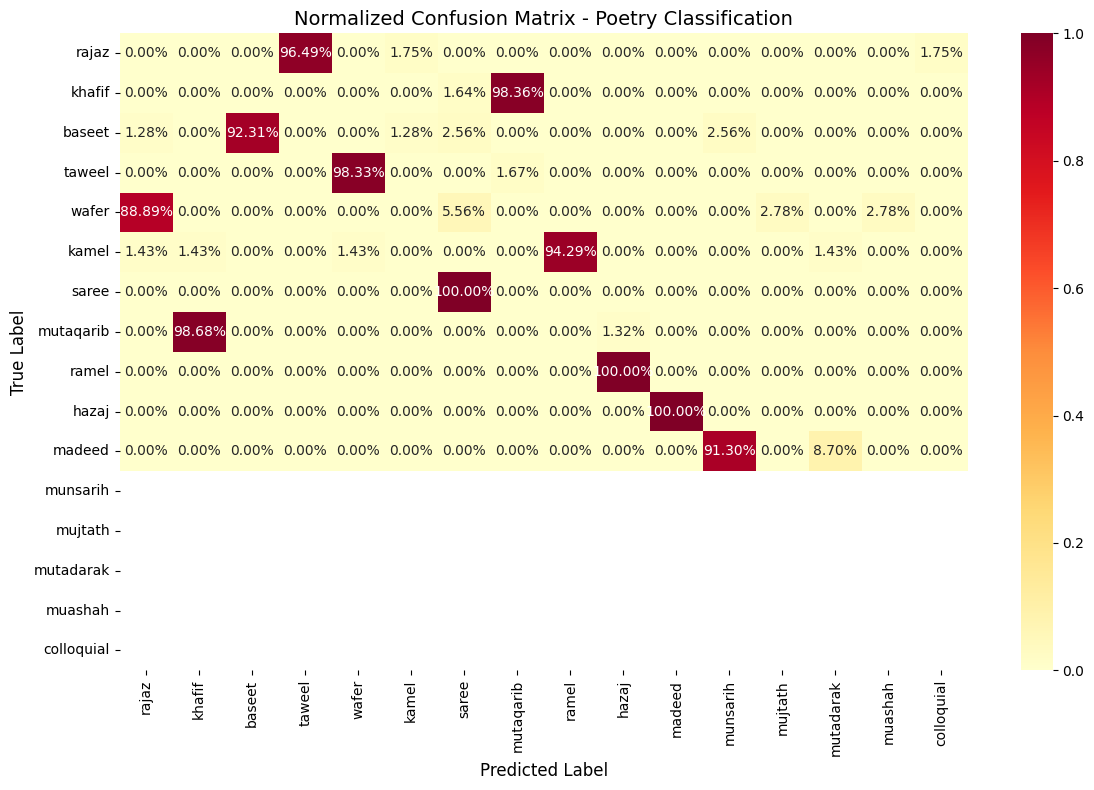

In [42]:
# ====================================================
# NORMALIZED CONFUSION MATRIX (Shows percentages)
# ====================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

# Normalize by row (true labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',xticklabels=unique_names,yticklabels=unique_names,vmin=0, vmax=1)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Normalized Confusion Matrix - Poetry Classification', fontsize=14)
plt.tight_layout()
plt.show()